# 6CS012 - Worksheet 5
## End-to-End CNN Model for Image Classification (Amazon Fruits Dataset)



## Setup & Imports

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
TRAIN_DIR = "/content/FruitinAmazon/train"
TEST_DIR  = "/content/FruitinAmazon/test"
# ──────────────────────────────────────────────────────────────────────────────

IMG_HEIGHT     = 128
IMG_WIDTH      = 128
BATCH_SIZE     = 16
EPOCHS         = 250
VALIDATION_SPLIT = 0.2
MODEL_SAVE_PATH  = "best_fruit_cnn.h5"

---
## Task 1 – Data Understanding and Visualization

### 1a. Display One Random Image Per Class

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


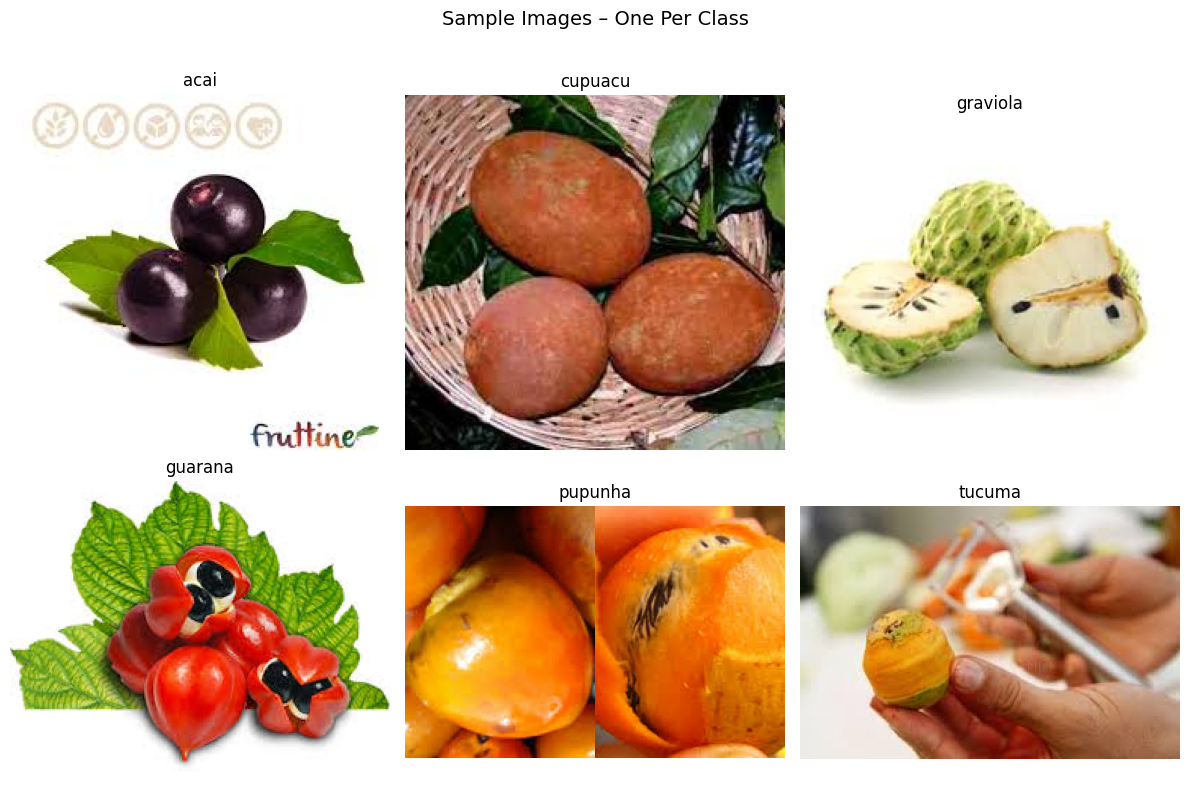

In [5]:
# Get sorted list of class directories
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_dirs)
print(f"Classes found ({num_classes}):", class_dirs)

# Pick one random image per class
sample_images = []
sample_labels = []
for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    chosen = random.choice(images)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

# Display in a grid with 2 rows
cols = (num_classes + 1) // 2   # ceiling division for balanced grid
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12)
    axes[i].axis("off")

# Hide any leftover axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Images – One Per Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:**  
The dataset contains images of 6 Amazon fruit classes: *acai, cupuacu, graviola, guarana, pupunha,* and *tucuma*.  
Images differ in colour, texture, shape, size, and background conditions, which represents a realistic multi-class classification challenge.

### 1b. Check for and Remove Corrupted Images

In [6]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        image_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(image_path)
            img.verify()          # checks integrity without fully loading
        except (IOError, SyntaxError):
            os.remove(image_path)
            corrupted.append(image_path)
            print(f"Removed corrupted image: {image_path}")

if not corrupted:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")

No corrupted images found.


---
## Task 2 – Loading and Preprocessing Image Data

In [8]:
# Rescaling layer – normalises pixel values from [0, 255] to [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# Training dataset
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=123,
)

# Grab class names before mapping
class_names = raw_train_ds.class_names
print("Class names:", class_names)
num_classes = len(class_names)

# Apply rescaling
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=123,
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123,
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


---
## Task 3 – Implement the CNN

In [9]:
model = keras.Sequential([
    # Convolutional Block 1
    layers.Conv2D(
        filters=32, kernel_size=(3, 3),
        padding="same", strides=(1, 1),
        activation="relu",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Block 2
    layers.Conv2D(
        filters=32, kernel_size=(3, 3),
        padding="same", strides=(1, 1),
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64,  activation="relu"),

    # Output Layer
    layers.Dense(num_classes, activation="softmax"),
], name="fruit_cnn")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "fruit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 – Compile and Train the Model

In [10]:
# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,          # stop after 20 epochs without improvement
    restore_best_weights=True,
    verbose=1,
)

# Train
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stopping_cb],
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.0924 - loss: 2.1271
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruit_cnn.h5



Epoch 1: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 362ms/step - accuracy: 0.0972 - loss: 2.1591 - val_accuracy: 0.0556 - val_loss: 1.6192
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.2406 - loss: 1.7002
Epoch 2: val_accuracy improved from 0.05556 to 0.50000, saving model to best_fruit_cnn.h5



Epoch 2: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.3333 - loss: 1.6426 - val_accuracy: 0.5000 - val_loss: 1.5421
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.4733 - loss: 1.3807
Epoch 3: val_accuracy improved from 0.50000 to 0.77778, saving model to best_fruit_cnn.h5



Epoch 3: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 0.5278 - loss: 1.3364 - val_accuracy: 0.7778 - val_loss: 1.0025
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6913 - loss: 1.0184
Epoch 4: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.6806 - loss: 0.9782 - val_accuracy: 0.4444 - val_loss: 1.0243
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8854 - loss: 0.6112
Epoch 5: val_accuracy improved from 0.77778 to 0.88889, saving model to best_fruit_cnn.h5



Epoch 5: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 0.8750 - loss: 0.5673 - val_accuracy: 0.8889 - val_loss: 0.6226
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8962 - loss: 0.3733
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.9028 - loss: 0.3539 - val_accuracy: 0.6667 - val_loss: 0.7411
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9712 - loss: 0.1749
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.9861 - loss: 0.1521 - val_accuracy: 0.8889 - val_loss: 0.5405
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9840 - loss: 0.0990
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.9722 - loss: 0.1004 - val_accuracy: 0.8333 - val_loss: 0.4594
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9799 - loss: 0

### Training Curves

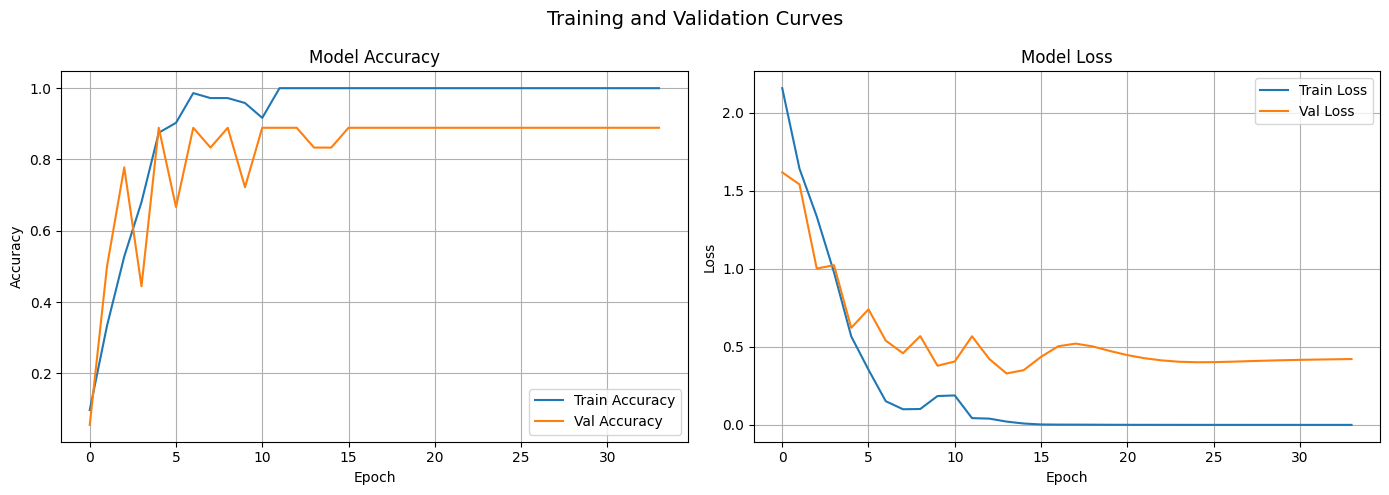

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history["accuracy"],     label="Train Accuracy")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history["loss"],     label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.suptitle("Training and Validation Curves", fontsize=14)
plt.tight_layout()
plt.show()

---
## Task 5 – Evaluate the Model

In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7000 - loss: 0.8122

Test Loss    : 0.8122
Test Accuracy: 0.7000


---
## Task 6 – Save and Load the Model

In [13]:
# The best model was already saved by ModelCheckpoint.
# Explicitly save the final model as well:
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# Load and re-evaluate
loaded_model = keras.models.load_model(MODEL_SAVE_PATH)
print("\nLoaded model summary:")
loaded_model.summary()

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model – Test Loss    : {loaded_loss:.4f}")
print(f"Loaded Model – Test Accuracy: {loaded_acc:.4f}")

Model saved to: best_fruit_cnn.h5

Loaded model summary:


Model: "fruit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,224 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7000 - loss: 0.8122

Loaded Model – Test Loss    : 0.8122
Loaded Model – Test Accuracy: 0.7000


---
## Task 7 – Predictions and Classification Report

In [14]:
# Collect all true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true        = np.array(y_true)
y_pred_probs  = np.array(y_pred_probs)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print("Sample predictions (first 10):")
for i in range(min(10, len(y_true))):
    print(f"  True: {class_names[y_true[i]]:12s}  |  Predicted: {class_names[y_pred_labels[i]]}")

Sample predictions (first 10):
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: cupuacu       |  Predicted: cupuacu
  True: cupuacu       |  Predicted: graviola
  True: cupuacu       |  Predicted: graviola
  True: cupuacu       |  Predicted: cupuacu
  True: cupuacu       |  Predicted: cupuacu


In [15]:
# Classification Report
report = classification_report(
    y_true,
    y_pred_labels,
    target_names=class_names,
    digits=2,
)
print("Classification Report\n")
print(report)

Classification Report

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.56      1.00      0.71         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.62      1.00      0.77         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.70        30
   macro avg       0.65      0.70      0.64        30
weighted avg       0.65      0.70      0.64        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


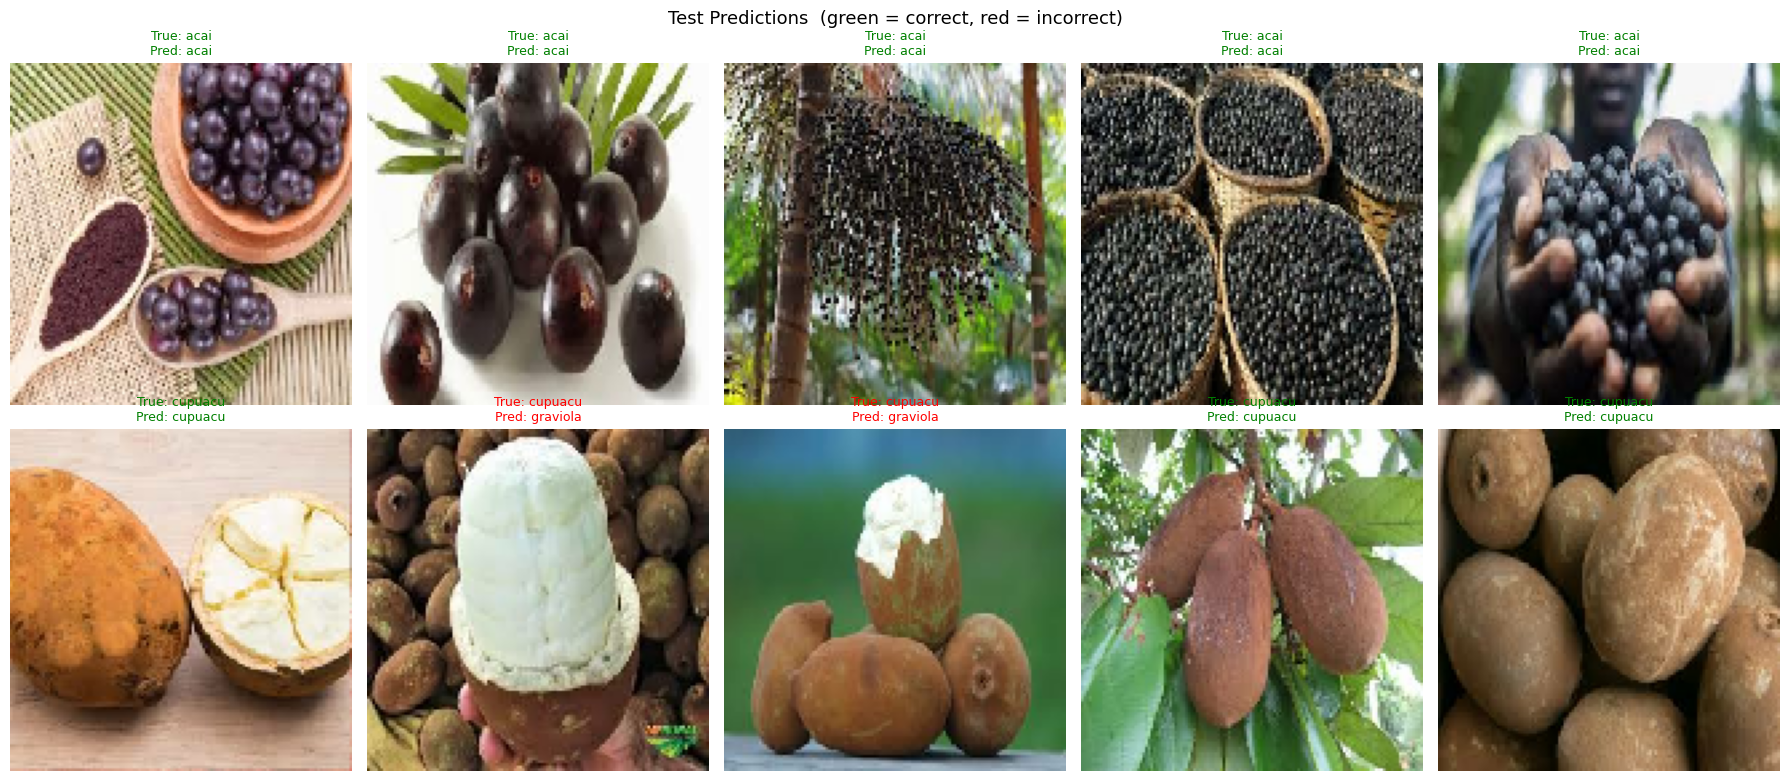

In [16]:
# Visualise a few test predictions
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

# Grab the first batch for display
sample_batch_images, sample_batch_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_batch_images, verbose=0), axis=1)

for i in range(min(10, len(sample_batch_images))):
    axes[i].imshow(sample_batch_images[i].numpy())
    true_label = class_names[sample_batch_labels[i]]
    pred_label = class_names[sample_preds[i]]
    colour = "green" if true_label == pred_label else "red"
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=colour, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Test Predictions  (green = correct, red = incorrect)", fontsize=13)
plt.tight_layout()
plt.show()